# Guia Didático e Matemático de Álgebra Linear e Machine Learning do Zero
Este notebook apresenta e explica detalhadamente o funcionamento dos algoritmos nas novas bibliotecas locais refatoradas. Para garantir uma arquitetura limpa e Pythônica, dividimos as responsabilidades do projeto em **4 camadas independentes**:

1. **`estatistica.py` (`est`)**: Médias, desvios, variâncias, correlação e covariâncias amostrais.
2. **`algebra.py` (`alg`)**: Vetores puros (ativação sigmoide) e álgebra matricial orientada a colunas.
3. **`probabilidades.py` (`prob`)**: Distribuições de probabilidade discretas (Binomial e Poisson).
4. **`machine_learning.py` (`ml`)**: Modelos preditivos de regressão linear e logística.

In [1]:
# Importando bibliotecas para suporte gráfico
import matplotlib.pyplot as plt
import seaborn as sns

# Importando a nossa arquitetura de 4 camadas locais
import estatistica as est
import algebra as alg
import probabilidades as prob
import machine_learning as ml

# Configuração estética dos gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

## 1. Estatística Descritiva e Primitivas Amostrais

As funções estatísticas foram extraídas para o módulo `estatistica.py` (`est`). Aqui descrevemos as medidas amostrais de dispersão e correlação linear.

### Média Aritmética simples ($\bar{x}$)
$$\bar{x} = \frac{1}{N} \sum_{i=1}^N x_i$$

### Variância Amostral Legítima ($s^2$)
Aplica a **Correção de Bessel** dividindo por $N-1$ para manter a estimativa populacional imparcial (sem viés):
$$s^2 = \frac{1}{N - 1} \sum_{i=1}^N (x_i - \bar{x})^2$$

### Covariância Amostral ($\text{Cov}(X, Y)$)
Mede o grau de variação conjunta entre duas variáveis aleatórias:
$$\text{Cov}(X, Y) = \frac{1}{N - 1} \sum_{i=1}^N (x_i - \bar{x})(y_i - \bar{y})$$

### Coeficiente de Correlação de Pearson ($r$)
Mapeia a covariância das variáveis em uma relação linear normalizada de $[-1, 1]$:
$$r = \frac{\text{Cov}(X, Y)}{s_x s_y} = \frac{N \sum xy - (\sum x)(\sum y)}{\sqrt{[N \sum x^2 - (\sum x)^2][N \sum y^2 - (\sum y)^2]}}$$

In [2]:
# Dados amostrais
x = [2, 3, 5, 7, 8]
y = [5, 7, 8, 10, 12]

# Executando a nova biblioteca 'est'
media_x = est.media(x)
variancia_x = est.variancia(x)
cov_xy = est.covariancia(x, y)
pearson = est.coeficiente_pearson(x, y)

print(f"--- Métricas Amostrais (Biblioteca 'est') ---")
print(f"Média de X: {media_x:.4f}")
print(f"Variância de X (Bessel): {variancia_x:.4f}")
print(f"Covariância XY: {cov_xy:.4f}")
print(f"Correlação de Pearson: {pearson:.4f}")

--- Métricas Amostrais (Biblioteca 'est') ---
Média de X: 5.0000
Variância de X (Bessel): 6.5000
Covariância XY: 6.7500
Correlação de Pearson: 0.9799


## 2. O Coração da Classificação: A Função Sigmoide Estável

A função Sigmoide mapeia números reais para probabilidades de $[0, 1]$:
$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

> **Estabilidade Numérica:** Para evitar `OverflowError` com valores negativos de $z$ na exponencial, utilizamos a forma estável reescrita:
> $$\sigma(z) = \frac{e^z}{1 + e^z} \quad \text{se } z < 0$$

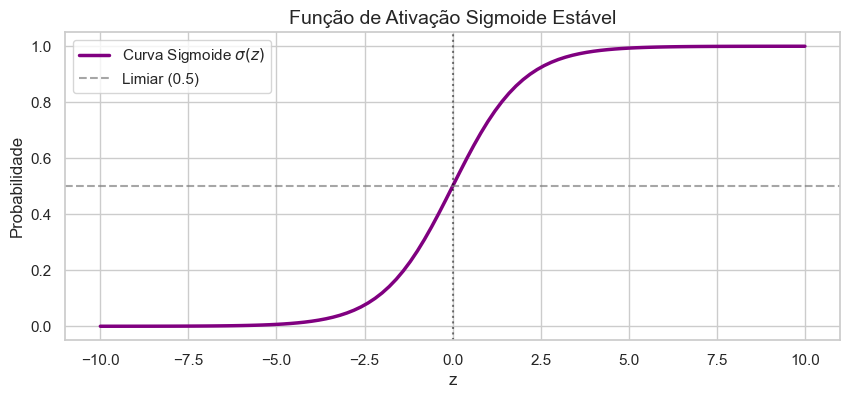

In [3]:
# Gerando curva Sigmoide
z_sweep = [i * 0.2 for i in range(-50, 51)]
probabilidades = [alg.sigmoide(z) for z in z_sweep]

plt.figure(figsize=(10, 4))
plt.plot(z_sweep, probabilidades, color="purple", linewidth=2.5, label="Curva Sigmoide $\\sigma(z)$")
plt.axhline(0.5, color="gray", linestyle="--", alpha=0.7, label="Limiar (0.5)")
plt.axvline(0, color="black", linestyle=":", alpha=0.5)
plt.title("Função de Ativação Sigmoide Estável", fontsize=14)
plt.xlabel("z")
plt.ylabel("Probabilidade")
plt.legend()
plt.show()

## 3. Álgebra Matricial Orientada a Colunas

Em `algebra.py` (`alg`), representamos matrizes como listas de colunas. A multiplicação matricial é feita de forma extremamente pythônica em apenas 4 linhas:
```python
linhas_m1 = list(zip(*matriz1))
return [
    [sum(a * b for a, b in zip(linha_a, coluna_b)) for linha_a in linhas_m1]
    for coluna_b in matriz2
]
```

In [4]:
# Criando matrizes para Equação Normal
intercepto = [1, 1, 1, 1, 1]
horas = [2, 3, 5, 7, 8]
qi = [100, 90, 105, 110, 115]

X_transposta = alg.criar_matriz(intercepto, horas, qi)
X_normal = alg.transpor_matriz(X_transposta)

# XtX = X^T * X
XtX = alg.multiplicar_matrizes(X_normal, X_transposta)
print(f"Covariância Matricial XtX (3x3):\n{XtX}")

Covariância Matricial XtX (3x3):
[[5, 25, 520], [25, 151, 2685], [520, 2685, 54450]]


### Matriz Inversa Simplificada

Graças ao isolamento da lógica matricial em `algebra.py`, invertemos matrizes de forma unificada chamando `alg.inverter_matriz(XtX)`, que processa:
1. Determinante por eliminação de Gauss (multiplicação da diagonal da matriz triangular superior).
2. Matriz de cofatores e adjunta transposta.
3. Multiplicação pelo inverso do determinante:
   $$A^{-1} = \frac{1}{\det(A)} \text{adj}(A)$$

In [5]:
# Determinante
triangular = alg.transformar_em_triangular(XtX)
det_XtX = alg.multiplicar_diagonal(triangular)
print(f"Determinante de XtX: {det_XtX:.4f}")

# Inversa unificada
inversa = alg.inverter_matriz(XtX)
print(f"\nMatriz Inversa (XtX)^-1:\n{inversa}")

Determinante de XtX: 11975.0000

Matriz Inversa (XtX)^-1:
[[84.5699373695198, 2.9185803757828803, -0.9515657620041751], [2.9185803757828803, 0.15448851774530267, -0.03549060542797494], [-0.9515657620041751, -0.03549060542797494, 0.010855949895615863]]


## 4. Distribuições de Probabilidade Discretas

No novo módulo `probabilidades.py` (`prob`), implementamos do zero os dois modelos fundamentais de probabilidade discreta.

### 4.1 Distribuição Binomial
Modeliza a probabilidade de obter exatamente $k$ sucessos em $n$ experimentos independentes de Bernoulli, com probabilidade de sucesso $p$. A **Função de Massa de Probabilidade (PMF)** é:
$$P(X = k) = \binom{n}{k} p^k (1 - p)^{n - k} \quad \text{onde} \quad \binom{n}{k} = \frac{n!}{k!(n-k)!}$$

A **Função de Distribuição Acumulada (CDF)** representa a probabilidade de obter no máximo $k$ sucessos ($X \leq k$):
$$P(X \leq k) = \sum_{i=0}^k \binom{n}{i} p^i (1 - p)^{n - i}$$

### 4.2 Distribuição de Poisson
Modeliza o número de eventos que ocorrem em um intervalo fixo de tempo ou espaço, dada uma taxa média $\lambda$ (lambda). A **PMF** é:
$$P(X = k) = \frac{\lambda^k e^{-\lambda}}{k!}$$

A **CDF** correspondente é:
$$P(X \leq k) = \sum_{i=0}^k \frac{\lambda^i e^{-\lambda}}{i!}$$

In [6]:
# 1. Testando os fatoriais e coeficientes binomiais
print(f"Fatorial de 5 (5!): {prob.fatorial(5)}")
print(f"Coeficiente binomial (10 escolhe 3): {prob.combinacao(10, 3)}")

# 2. Calculando probabilidades Binomiais (Exemplo: 5 lançamentos de moeda honesta)
prob_2_caras = prob.binomial_pmf(2, 5, 0.5)
prob_ate_2_caras = prob.binomial_cdf(2, 5, 0.5)
print(f"\nBinomial (Lançamento de Moedas):")
print(f"- P(Exatamente 2 caras em 5 tentativas): {prob_2_caras:.4%}")
print(f"- P(No máximo 2 caras em 5 tentativas): {prob_ate_2_caras:.4%}")

# 3. Calculando probabilidades de Poisson (Exemplo: Média de 3 acidentes por dia)
prob_2_acidentes = prob.poisson_pmf(2, 3)
prob_ate_2_acidentes = prob.poisson_cdf(2, 3)
print(f"\nPoisson (Ocorrência de Eventos - taxa=3):")
print(f"- P(Exatamente 2 eventos ocorrerem): {prob_2_acidentes:.4%}")
print(f"- P(No máximo 2 eventos ocorrerem): {prob_ate_2_acidentes:.4%}")

Fatorial de 5 (5!): 120
Coeficiente binomial (10 escolhe 3): 120

Binomial (Lançamento de Moedas):
- P(Exatamente 2 caras em 5 tentativas): 31.2500%
- P(No máximo 2 caras em 5 tentativas): 50.0000%

Poisson (Ocorrência de Eventos - taxa=3):
- P(Exatamente 2 eventos ocorrerem): 22.4042%
- P(No máximo 2 eventos ocorrerem): 42.3190%


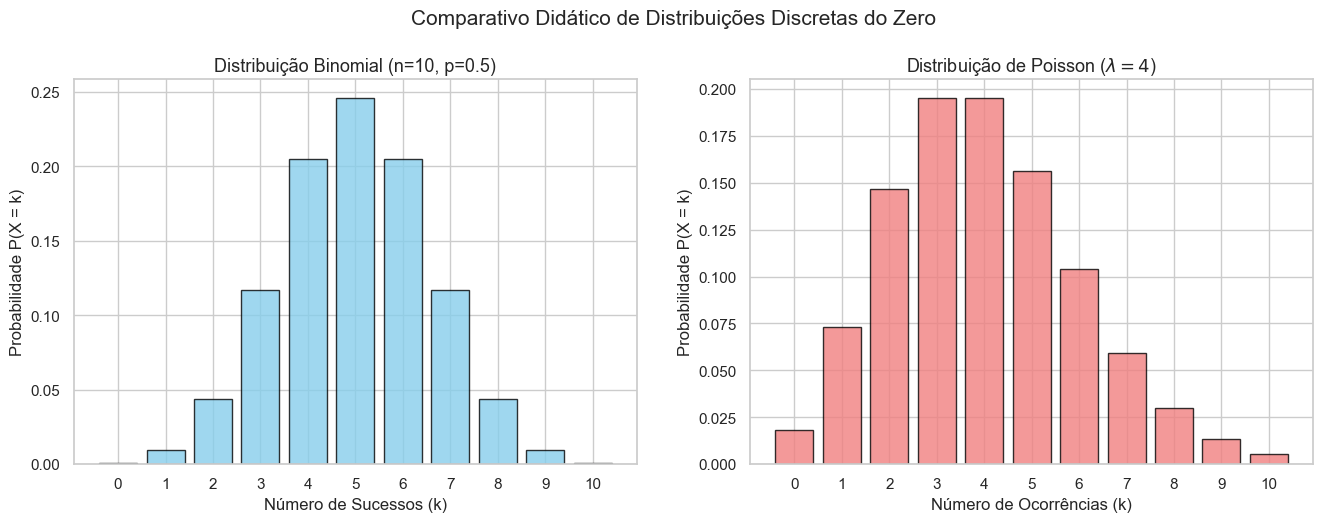

In [7]:
# Gerando sweep de k para plotagem
k_values = list(range(0, 11))

# Distribuição Binomial (n=10, p=0.5)
binomial_probs = [prob.binomial_pmf(ki, 10, 0.5) for ki in k_values]

# Distribuição de Poisson (lambda=4)
poisson_probs = [prob.poisson_pmf(ki, 4) for ki in k_values]

# Criando os plots didáticos
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico Binomial
ax[0].bar(k_values, binomial_probs, color="skyblue", edgecolor="black", alpha=0.8)
ax[0].set_title("Distribuição Binomial (n=10, p=0.5)", fontsize=13)
ax[0].set_xlabel("Número de Sucessos (k)")
ax[0].set_ylabel("Probabilidade P(X = k)")
ax[0].set_xticks(k_values)

# Gráfico Poisson
ax[1].bar(k_values, poisson_probs, color="lightcoral", edgecolor="black", alpha=0.8)
ax[1].set_title("Distribuição de Poisson ($\\lambda=4$)", fontsize=13)
ax[1].set_xlabel("Número de Ocorrências (k)")
ax[1].set_ylabel("Probabilidade P(X = k)")
ax[1].set_xticks(k_values)

plt.suptitle("Comparativo Didático de Distribuições Discretas do Zero", fontsize=15, y=1.02)
plt.show()

## 5. Modelos de Machine Learning e Otimização

### 5.1 Regressão Linear Simples: MQO vs Gradiente Descendente

#### MQO (Mínimos Quadrados Ordinários - Analítico)
Com nossa nova covariância estatística, a inclinação ($\beta_1$) da reta é descrita de forma muito expressiva:
$$\beta_1 = \frac{\text{Covariância}(X, Y)}{\text{Variância}(X)} = \frac{s_{xy}}{s^2_x}$$
$$\beta_0 = \bar{y} - \beta_1 \bar{x}$$

#### Gradiente Descendente (Iterativo)
Minimiza a Log-Loss / MSE corrigindo os pesos iterativamente:
$$\beta_1 \leftarrow \beta_1 - \alpha \left( -\frac{2}{N} \sum_{i=1}^N (y_i - \hat{y}_i)x_i \right)$$

MQO Analítico -> Beta 1: 1.0385 | Beta 0: 3.2077
GD Iterativo  -> Beta 1: 1.0385 | Beta 0: 3.2076


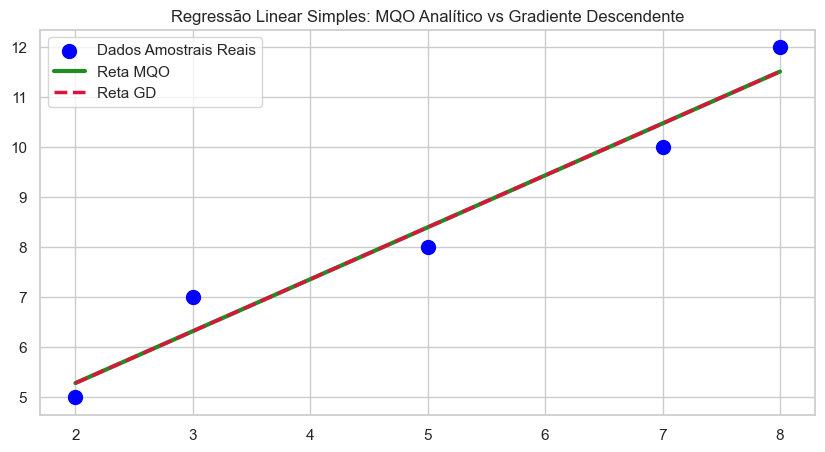

In [8]:
# MQO
beta1_mqo, beta0_mqo = ml.minimos_quadrados(x, y)

# GD
modelo_gd = ml.RegressaoLinear().fit(x, y, metodo="gd", taxa_aprendizado=0.01, epocas=3000)

print(f"MQO Analítico -> Beta 1: {beta1_mqo:.4f} | Beta 0: {beta0_mqo:.4f}")
print(f"GD Iterativo  -> Beta 1: {modelo_gd.coef_angular:.4f} | Beta 0: {modelo_gd.coef_linear:.4f}")

# Plotando a reta ajustada
y_pred_mqo = ml.realizar_previsao(x, beta1_mqo, beta0_mqo)
y_pred_gd = modelo_gd.predict(x)

plt.figure(figsize=(10, 5))
plt.scatter(x, y, color="blue", s=100, label="Dados Amostrais Reais")
plt.plot(x, y_pred_mqo, color="forestgreen", linewidth=3, label="Reta MQO")
plt.plot(x, y_pred_gd, color="crimson", linestyle="--", linewidth=2.5, label="Reta GD")
plt.title("Regressão Linear Simples: MQO Analítico vs Gradiente Descendente")
plt.legend()
plt.show()

### 5.2 Regressão Linear Múltipla via Equação Normal

Resolvemos as regressões de multiplas dimensões com a clássica **Equação Normal**:
$$\beta = (X^T X)^{-1} X^T y$$

Nosso `fit` em `RegressaoLinearMultipla` é limpo e direto, abstraindo a inversão para o módulo `algebra.py`.

In [9]:
notas_reais = [5, 7, 8, 10, 12]

modelo_multiplo = ml.RegressaoLinearMultipla().fit(X_transposta, notas_reais)
print(f"Vetor de Coeficientes Beta: {modelo_multiplo.coeficientes}")

previsoes = modelo_multiplo.predict(X_transposta)
metricas = ml.rmse(notas_reais, previsoes)
print(f"RMSE: {metricas['RMSE']:.6f} | MSE: {metricas['MSE']:.6f}")

Vetor de Coeficientes Beta: [9.173277661795055, 1.260960334029221, -0.06805845511482289]
RMSE: 0.383370 | MSE: 0.146973


### 5.3 Regressão Logística

Para problemas de classificação, estimamos probabilidades usando sigmoide e otimizando a Log-Loss via GD:
$$\beta_{j} \leftarrow \beta_{j} - \alpha \frac{1}{N}\sum_{i=1}^N (\hat{y}_i - y_i)x_{ij}$$
$$\beta_{0} \leftarrow \beta_{0} - \alpha \frac{1}{N}\sum_{i=1}^N (\hat{y}_i - y_i)$$

Peso calibrado: 2.0652 | Bias calibrado: -7.9489


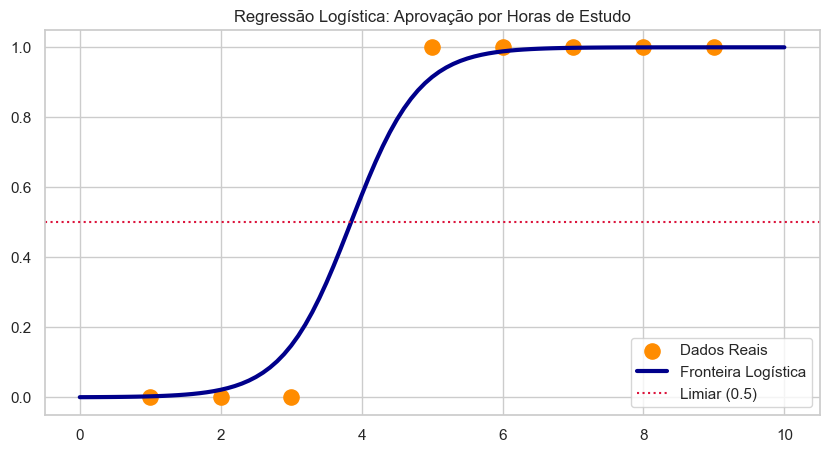

In [10]:
X_estudo = [1, 2, 3, 5, 6, 7, 8, 9]
y_resultado = [0, 0, 0, 1, 1, 1, 1, 1]

peso_otimo, bias_otimo = ml.treinar_logistica(X_estudo, y_resultado, taxa_aprendizado=0.2, epocas=1500)
print(f"Peso calibrado: {peso_otimo:.4f} | Bias calibrado: {bias_otimo:.4f}")

# Curva suave de probabilidades
x_linha = [i * 0.1 for i in range(0, 101)]
y_probabilidades = [alg.predizer_probabilidade(xi, peso_otimo, bias_otimo) for xi in x_linha]

plt.figure(figsize=(10, 5))
plt.scatter(X_estudo, y_resultado, color="darkorange", s=120, label="Dados Reais")
plt.plot(x_linha, y_probabilidades, color="darkblue", linewidth=3, label="Fronteira Logística")
plt.axhline(0.5, color="crimson", linestyle=":", label="Limiar (0.5)")
plt.title("Regressão Logística: Aprovação por Horas de Estudo")
plt.legend(loc="lower right")
plt.show()

## Conclusão

Neste notebook, exploramos uma arquitetura de Machine Learning robusta baseada em **4 camadas de código limpo**:
1. **Estatística (`est`)**: Operando de forma independente com covariâncias e variâncias corretas.
2. **Álgebra Linear (`alg`)**: Focada em vetores puros e matrizes robustas por colunas.
3. **Teoria de Probabilidade (`prob`)**: Cobrindo modelos e plotagens de distribuições discretas de Binomial e Poisson.
4. **Modelagem de ML (`ml`)**: Modelos desacoplados com alto teor prático e didático.

Este design reflete o padrão ouro de código limpo, legibilidade e performance para engenharia computacional!